## How to use this notebook

- **Single-run cells**: The first few code cells run one set of simulations for the three AI policies and are used by any Gantt or single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per policy and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [40]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 1200
RANDOM_SEED = 36
INTER_ARRIVAL_TIME = 0.0  # run permits back-to-back

In [41]:
# Run all three simulations
print(f"Running standard simulation with {NUM_PERMITS} permits...")
# Edit these values to test additional assumptions.
SIMULATION_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "simulation_duration": None,
    "pct_pre_approved": 0.02,
    "pct_custom": 0.90,
    "pct_self_cert": 0.08,
    "pct_like_for_like": 0.80,
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 1,
    "fire_caseload_per_staff": 7,
}

common_run_kwargs = {
    "num_permits": NUM_PERMITS,
    "random_seed": RANDOM_SEED,
    "inter_arrival_time": INTER_ARRIVAL_TIME,
    **SIMULATION_PARAMS,
}

sim_standard = run_simulation(
    **common_run_kwargs,
    ai_review="none",
)

print(f"\nRunning initial AI check simulation with {NUM_PERMITS} permits...")
sim_initial = run_simulation(
    **common_run_kwargs,
    ai_review="initial_check",
)

print(f"\nRunning full AI review simulation with {NUM_PERMITS} permits...")
sim_full = run_simulation(
    **common_run_kwargs,
    ai_review="full_review",
)

Running standard simulation with 1200 permits...

Running initial AI check simulation with 1200 permits...

Running full AI review simulation with 1200 permits...


In [42]:
# Print statistics for each process
print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("=== AI INITIAL CHECK PROCESS ===")
stats_initial = sim_initial.get_statistics()
print_statistics(stats_initial)

print("\n=== AI FULL REVIEW PROCESS ===")
stats_full = sim_full.get_statistics()
print_statistics(stats_full)

=== STANDARD PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 1200
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :  835 (69.58%)
  CUSTOM_NON_LIKE               :  251 (20.92%)
  PRE_APPROVED_LIKE             :   18 ( 1.50%)
  PRE_APPROVED_NON_LIKE         :    7 ( 0.58%)
  SELF_CERT_LIKE                :   70 ( 5.83%)
  SELF_CERT_NON_LIKE            :   19 ( 1.58%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     528.83 days
  Median:   533.01 days
  Std Dev:  228.51 days
  Min:       94.01 days
  Max:     1381.76 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT
-

In [47]:
# Run multiple simulations for each AI scenario to see aggregate behavior
N_RUNS = 100

# Edit these values to test additional assumptions across all AI scenarios.
SIMULATION_DURATION = None
MULTI_RUN_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "pct_pre_approved": 0.02,
    "pct_custom": 0.90,
    "pct_self_cert": 0.08,
    "pct_like_for_like": 0.80,
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 2,
    "fire_caseload_per_staff": 7,
}

scenario_params_list = [
    {"name": "Standard", **MULTI_RUN_PARAMS, "ai_review": "none"},
    {"name": "Initial AI Check", **MULTI_RUN_PARAMS, "ai_review": "initial_check"},
    {"name": "Full AI Review", **MULTI_RUN_PARAMS, "ai_review": "full_review"},
]

multi_run_kwargs = {
    "n_runs": N_RUNS,
    "num_permits": NUM_PERMITS,
    "simulation_duration": SIMULATION_DURATION,
    "base_seed": RANDOM_SEED,
    "inter_arrival_time": INTER_ARRIVAL_TIME,
    "scenario_params_list": scenario_params_list,
    "collect_permits": True,
}

multi_results = run_multiple_simulations(**multi_run_kwargs)

all_standard_permits: list = []
all_initial_permits: list = []
all_full_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Initial AI Check":
        all_initial_permits.extend(permits)
    elif scenario == "Full AI Review":
        all_full_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {N_RUNS} runs per scenario (AI policies). Aggregate total-time stats:")
_print_summary("Standard", all_standard_permits)
_print_summary("Initial AI Check", all_initial_permits)
_print_summary("Full AI Review", all_full_permits)

Ran 100 runs per scenario (AI policies). Aggregate total-time stats:
Standard: n=120000, mean=473.96, median=470.17
Initial AI Check: n=120000, mean=399.03, median=393.64
Full AI Review: n=120000, mean=353.67, median=344.70


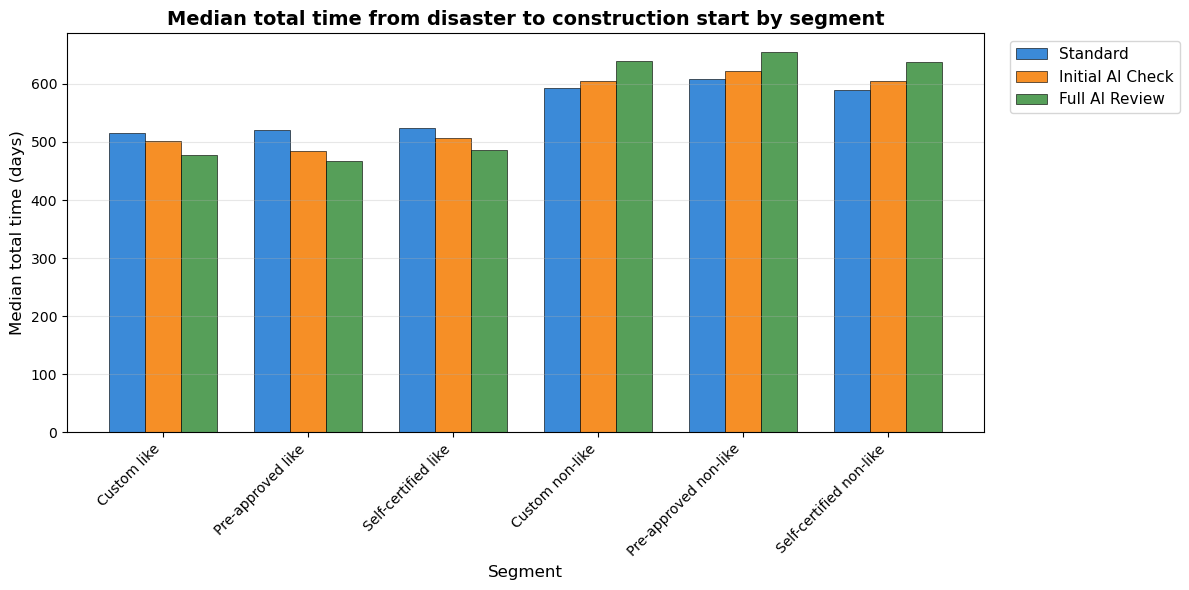

In [44]:
# Compare median total time (disaster to construction) by segment
# Use aggregated permits across many runs for each scenario
permits_by_process = {
    "Standard": all_standard_permits,
    "Initial AI Check": all_initial_permits,
    "Full AI Review": all_full_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()

In [48]:
# Diagnostic: non-like-for-like step-level timeline comparison by AI policy
import pandas as pd
from permit_simulation import Segment

NON_LIKE_SEGMENTS = {
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
}


def _non_like_step_summary(permits: list) -> dict:
    non_like = [p for p in permits if p.segment in NON_LIKE_SEGMENTS and p.ready_for_construction is not None]
    if not non_like:
        return {"n": 0}

    def _mean(values):
        vals = [v for v in values if v is not None]
        return float(np.mean(vals)) if vals else np.nan

    return {
        "n": len(non_like),
        "total_time": _mean([p.ready_for_construction - p.created_at for p in non_like]),
        "planning_wait": _mean([p.planning_total_waiting for p in non_like]),
        "planning_service": _mean([p.planning_initial_service + p.planning_recheck_service for p in non_like]),
        "public_works_wait": _mean([p.public_works_total_waiting for p in non_like]),
        "public_works_service": _mean([p.public_works_initial_service + p.public_works_recheck_service for p in non_like]),
        "fire_wait": _mean([p.fire_review_total_waiting for p in non_like]),
        "fire_service": _mean([p.fire_initial_service + p.fire_recheck_service for p in non_like]),
        "agency_referral_total": _mean([
            (p.agency_referral_end - p.agency_referral_request)
            if p.agency_referral_request is not None and p.agency_referral_end is not None
            else 0.0
            for p in non_like
        ]),
        "special_zoning_service": _mean([
            (p.zoning_end - p.zoning_start)
            if p.zoning_start is not None and p.zoning_end is not None
            else 0.0
            for p in non_like
        ]),
        "applicant_revisions": _mean([p.applicant_revisions_total_time for p in non_like]),
    }


scenario_non_like = {
    "Standard": _non_like_step_summary(all_standard_permits),
    "Initial AI Check": _non_like_step_summary(all_initial_permits),
    "Full AI Review": _non_like_step_summary(all_full_permits),
}

comparison_df = pd.DataFrame(scenario_non_like).T
comparison_df = comparison_df[[
    "n",
    "total_time",
    "planning_wait",
    "planning_service",
    "public_works_wait",
    "public_works_service",
    "fire_wait",
    "fire_service",
    "agency_referral_total",
    "special_zoning_service",
    "applicant_revisions",
]].round(2)

print("Non-like-for-like diagnostics (mean days):")
display(comparison_df)

if "Standard" in comparison_df.index:
    delta_vs_standard = (comparison_df - comparison_df.loc["Standard"]).round(2)
    print("\nDelta vs Standard (mean days):")
    display(delta_vs_standard)


Non-like-for-like diagnostics (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,23935.0,530.76,141.00,10.0,0.41,8.30,0.10,4.71,38.77,57.35,95.26
Initial AI Check,23935.0,454.89,69.63,7.3,0.24,6.12,1.21,4.66,38.48,57.49,95.45
Full AI Review,23935.0,408.85,0.00,1.0,0.00,0.83,46.64,4.72,38.20,57.58,108.56



Delta vs Standard (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Initial AI Check,0.0,-75.87,-71.37,-2.7,-0.17,-2.18,1.11,-0.05,-0.29,0.14,0.19
Full AI Review,0.0,-121.91,-141.00,-9.0,-0.41,-7.47,46.54,0.01,-0.57,0.23,13.30


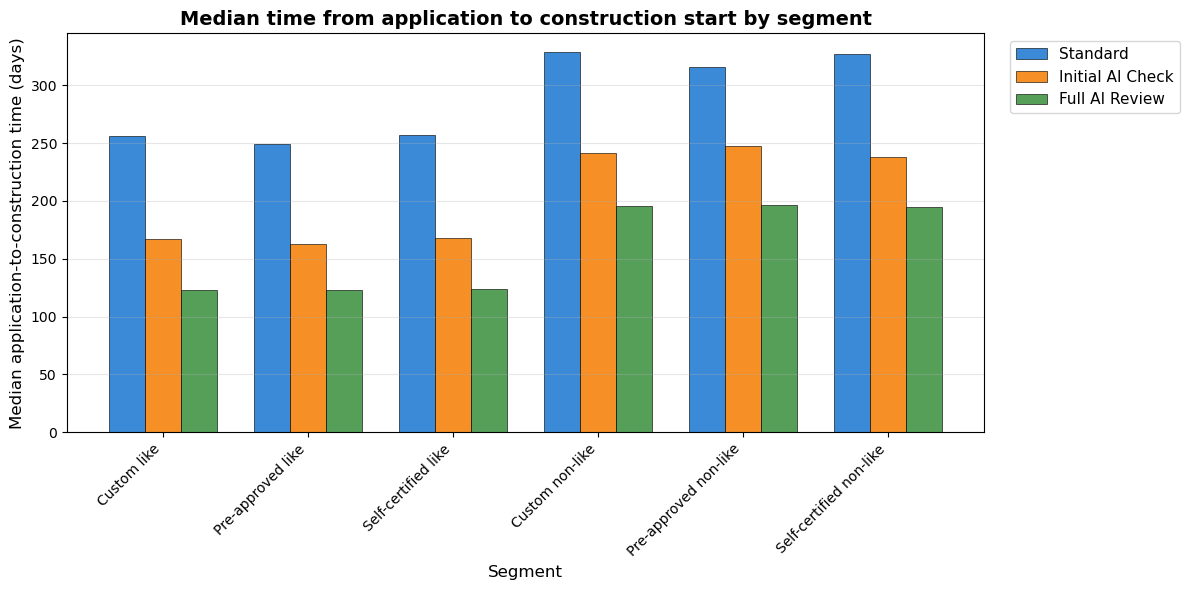

In [49]:
# Compare median time from application to construction by segment
from permit_simulation import Segment

permits_by_process = {
    "Standard": all_standard_permits,
    "Initial AI Check": all_initial_permits,
    "Full AI Review": all_full_permits,
}

segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
segment_labels = [
    "Custom like",
    "Pre-approved like",
    "Self-certified like",
    "Custom non-like",
    "Pre-approved non-like",
    "Self-certified non-like",
]

process_names = list(permits_by_process.keys())
medians = {pname: {} for pname in process_names}

for pname, permits in permits_by_process.items():
    for seg in segment_order:
        times = [
            p.ready_for_construction - p.planning_request
            for p in permits
            if p.segment == seg
            and p.ready_for_construction is not None
            and p.planning_request is not None
        ]
        medians[pname][seg] = float(np.median(times)) if times else np.nan

segments_to_plot = [
    seg for seg in segment_order
    if any(not np.isnan(medians[pname].get(seg, np.nan)) for pname in process_names)
]

if not segments_to_plot:
    print("No application-to-construction data available to plot.")
else:
    labels = [segment_labels[segment_order.index(seg)] for seg in segments_to_plot]
    x = np.arange(len(segments_to_plot))
    width = 0.25
    n_processes = len(process_names)

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = {
        "Standard": "#1976D2",
        "Initial AI Check": "#F57C00",
        "Full AI Review": "#388E3C",
    }

    for i, pname in enumerate(process_names):
        offset = width * (i - (n_processes - 1) / 2)
        values = [medians[pname].get(seg, np.nan) for seg in segments_to_plot]
        values = [v if not np.isnan(v) else 0 for v in values]
        ax.bar(
            x + offset,
            values,
            width,
            label=pname,
            color=colors.get(pname, "#888888"),
            alpha=0.85,
            edgecolor="black",
            linewidth=0.5,
        )

    ax.set_ylabel("Median application-to-construction time (days)", fontsize=12)
    ax.set_xlabel("Segment", fontsize=12)
    ax.set_title(
        "Median time from application to construction start by segment",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
